In [8]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

ROOT = Path.cwd().parent  # notebooks/ -> watson/
APP = ROOT / "backend" / "app"

load_dotenv(
    ROOT / ".env"
)  # before app imports: config.py instantiates Settings() at import
os.environ["POSTGRES_HOST"] = (
    "localhost"  # kernel is on the host, where `db` doesn't resolve
)
if str(APP) not in sys.path:
    sys.path.insert(0, str(APP))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from config import settings
import logfire

logfire.configure(
    token=settings.LOGFIRE_TOKEN,
    send_to_logfire="if-token-present",
    environment=settings.APP_ENV,
    scrubbing=False,
    service_name="watson",
    distributed_tracing=True,
)

logfire.instrument_pydantic_ai()
logfire.instrument_httpx()
logfire.instrument_openai()

Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [10]:
from datetime import date, datetime, time
from decimal import Decimal
from typing import Any

from psycopg.rows import dict_row

from db.readonly import async_readonly_connection

MAX_ROWS = 5000  # a scatter of every transaction is fine; a cartesian join is not


def _jsonable(value: Any) -> Any:
    """Whatever psycopg hands back, in a shape Monty and Vega-Lite both accept."""
    if value is None or isinstance(value, (bool, int, float, str)):
        return value
    if isinstance(value, (datetime, date, time)):
        return value.isoformat()
    if isinstance(value, Decimal):
        return float(value)
    if isinstance(value, (list, tuple)):  # text[] tags, arrays
        return [_jsonable(v) for v in value]
    if isinstance(value, dict):  # json / jsonb
        return {str(k): _jsonable(v) for k, v in value.items()}
    return str(value)  # uuid, interval, range, inet, bytes: anything else


async def query_database(plan: str, query: str) -> list[dict[str, Any]]:
    """
    Query the database and return the results as a list of dictionaries.
    """
    async with async_readonly_connection() as conn:
        async with conn.cursor(row_factory=dict_row) as cursor:
            await cursor.execute(query)  # type: ignore[arg-type]
            if cursor.description is None:  # a statement with no result set
                return []
            rows = await cursor.fetchmany(MAX_ROWS + 1)

    if len(rows) > MAX_ROWS:
        # Truncating silently would have the model chart a partial answer as a whole one.
        raise ValueError(
            f"query returned more than {MAX_ROWS} rows; aggregate it in SQL or add a LIMIT"
        )
    return [{k: _jsonable(v) for k, v in row.items()} for row in rows]

Logfire project URL: https://logfire-us.pydantic.dev/suban244/watson


In [11]:
import asyncio
import json
from typing import Any

import vl_convert as vlc

CHARTS: list[bytes] = []


async def plot_spec(spec: dict[str, Any]) -> str:
    """Render a Vega-Lite v5 spec and show the chart to the user.

    Put the rows inline under `data.values` as a list of records — never a url —
    and encode them with `mark` plus `encoding`, e.g.

        plot_spec({
            "title": "Expenses by category",
            "data": {"values": [{"category": "food", "amount": 10868.6},
                                {"category": "transport", "amount": 5843.0}]},
            "mark": "bar",
            "encoding": {
                "y": {"field": "category", "type": "nominal", "sort": "-x"},
                "x": {"field": "amount", "type": "quantitative"},
            },
        })

    Layer, facet, `rule` marks for averages or budgets and `text` marks for direct
    labels are all available. Amounts are NPR.

    Returns a short confirmation, not the image: the user sees the chart, you do not.
    """
    if isinstance(spec.get("data"), dict) and "url" in spec["data"]:
        return "chart not rendered: inline data only, put the rows in data.values"
    try:
        # to_thread: rasterising blocks, and in the bot this loop is serving Discord.
        png = await asyncio.to_thread(vlc.vegalite_to_png, json.dumps(spec), scale=2)
    except (
        Exception
    ) as e:  # invalid spec: hand the message back so the model can fix it
        return f"chart not rendered: {e}"
    CHARTS.append(png)
    return f"chart shown to the user ({len(png) // 1024} KB PNG)"

In [12]:
from pydantic_ai import Agent, Tool
from pydantic_ai_harness import CodeMode

from bot.agent.watson import make_model
from bot.capabilities.database import SCHEMA_REFERENCE

agent = Agent(
    model=make_model(),
    instructions=(
        "You are a helpful assistant that can answer questions about the user's "
        "finances. Amounts are NPR. When the user asks to see, plot, chart or "
        "visualise something, query the data first and then call `plot_spec` with "
        "a Vega-Lite spec built from it; keep the accompanying text short, since "
        "they can see the chart."
    ),
    capabilities=[CodeMode()],
    # The description carries the generated CREATE TABLE, so the model writes SQL
    # against the real schema instead of discovering it a query at a time.
    tools=[
        Tool(
            query_database,
            description=(
                "Run one read-only SELECT and return the rows.\n"
                "`tags` is a text[] of tag slugs: match it with `'slug' = ANY(tags)`, "
                "never with `=`.\n"
                f"Schema:\n{SCHEMA_REFERENCE}"
            ),
        ),
        plot_spec,
    ],
)

21:57:06.013 agent run
21:57:06.018   chat openai/gpt-5.6-luna
21:57:06.019     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
21:57:08.747   running tool: run_code
21:57:08.814     running tool: query_database
21:57:08.886   chat openai/gpt-5.6-luna
21:57:08.887     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
21:57:12.525   running tool: run_code
21:57:12.529     running tool: plot_spec
21:57:12.658   chat openai/gpt-5.6-luna
21:57:12.660     Chat Completion with 'openai/gpt-5.6-luna' [LLM]


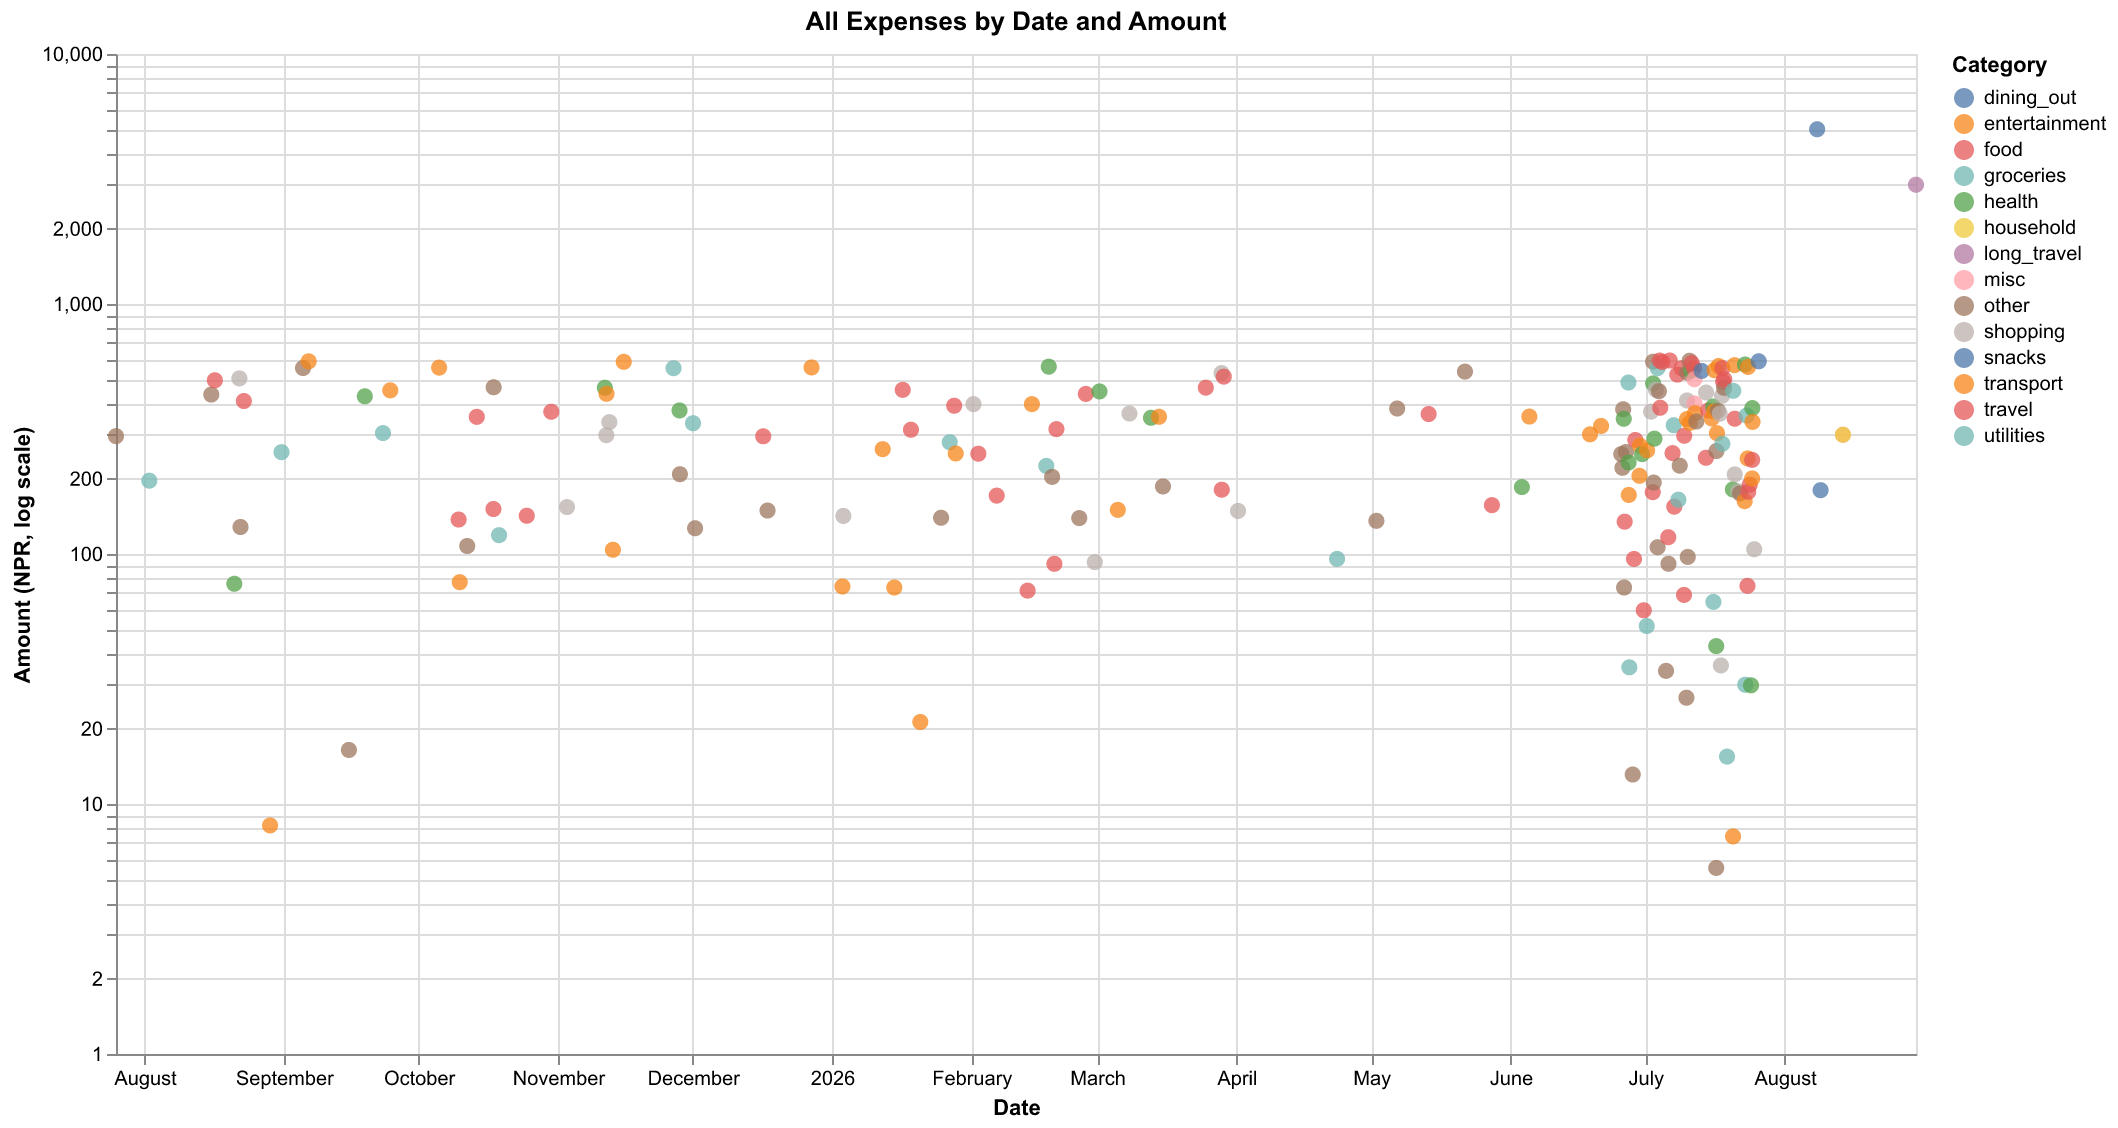

'Scatter plot created with amount on a logarithmic scale, date on the x-axis, and categories color-coded.'

In [13]:
from IPython.display import Image, display

CHARTS.clear()
result = await agent.run(
    "scatter plot of all my expenses by amount and date, with category color, log scaled"
)


for png in CHARTS:
    display(Image(png))
result.output